In [24]:
from pylib.preamble import *
enable_autoreload()

from pylib.fig_setup import PALETTE, STYLE, LW, SEC_PALETTE, style_ax, legend, country_handles

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Assess `GVA data` before decomposition

In [25]:
df = pd.read_parquet("0_intermediate/df.parquet")

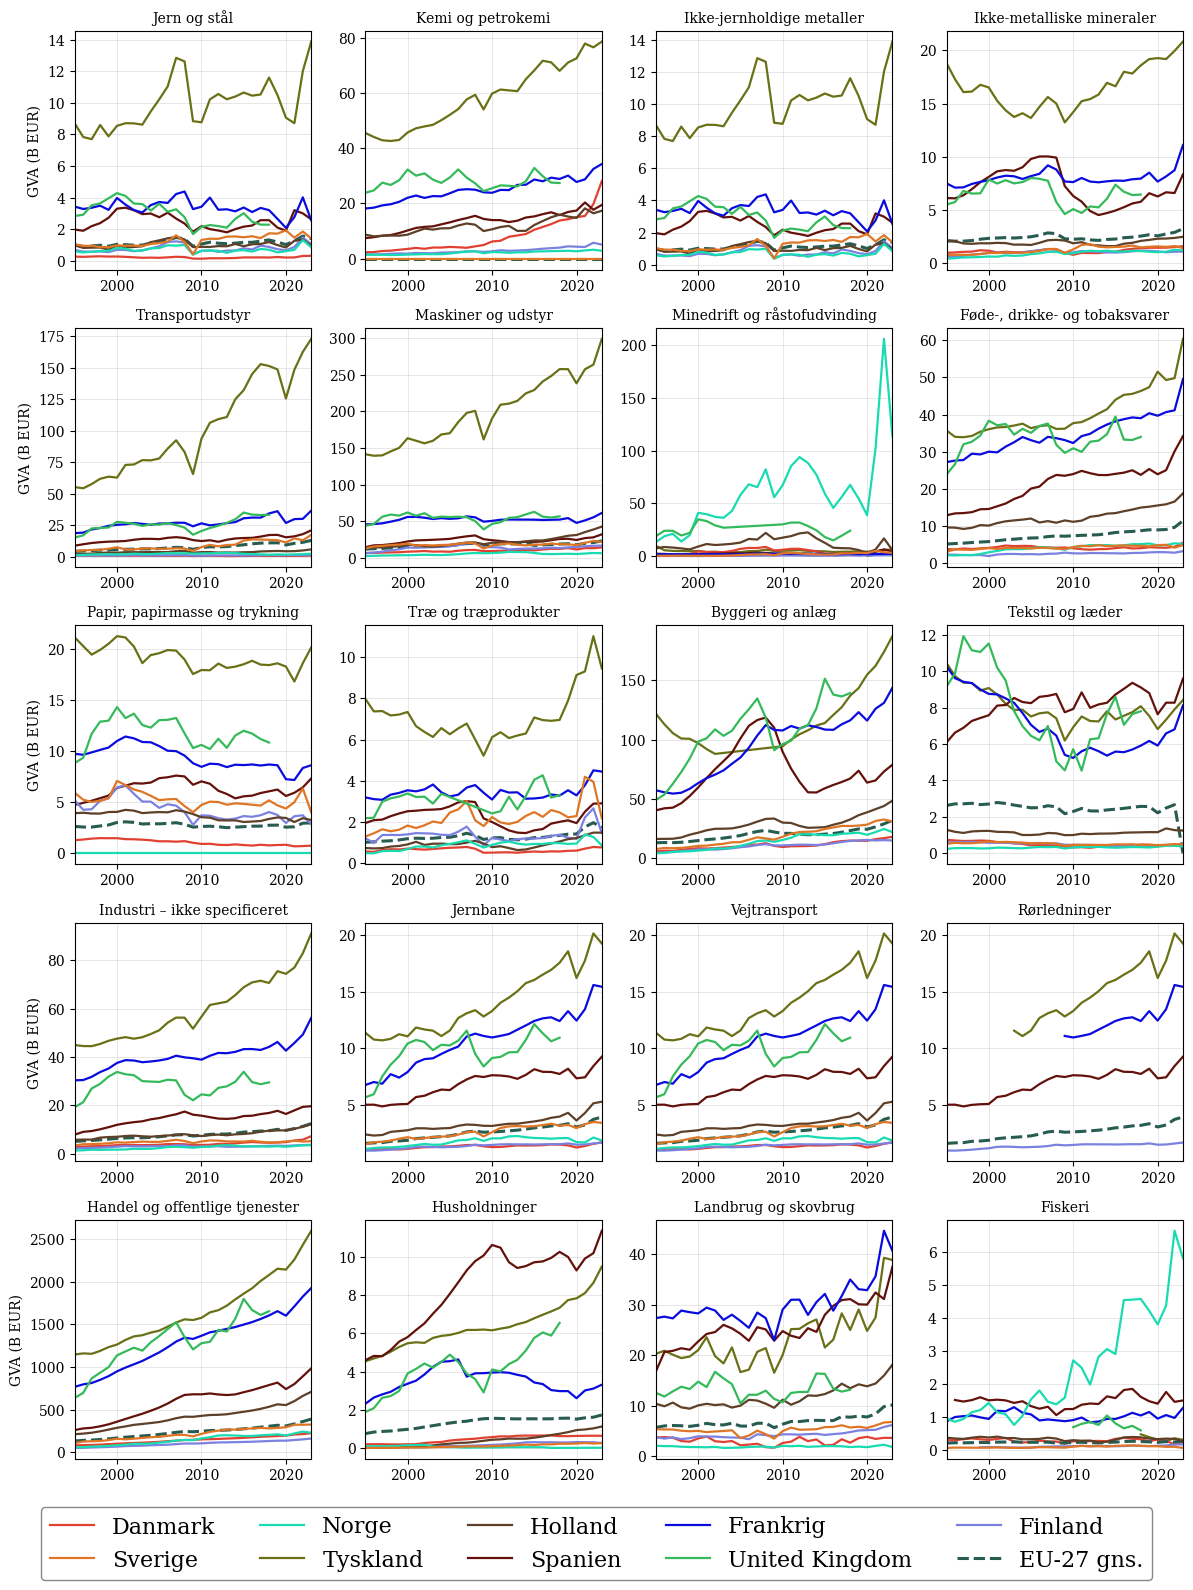

In [26]:
# Fig 1 — all sectors, all countries, 4 columns
df_plot = df.copy()
df_plot.loc[df_plot["geo"] == "EU27_2020", "gva_meur"] /= 27
df_plot["gva_bn"] = df_plot["gva_meur"] / 1000

available   = set(df_plot["nrg_bal"].unique())
sectors_all = [s for s in var_groups.subs if s in available]
NCOLS = 4
NROWS = -(-len(sectors_all) // NCOLS)

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(12, 3.0 * NROWS))
axes_flat = axes.flatten()

for i, (ax, nrg) in enumerate(zip(axes_flat, sectors_all)):
    sub = df_plot[df_plot["nrg_bal"] == nrg]
    for geo, grp in sub.groupby("geo"):
        grp = grp.sort_values("year")
        ax.plot(grp["year"], grp["gva_bn"],
                ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo])
    style_ax(ax, sub["year"], step=10)
    ax.set_title(var_groups.labels[nrg], fontsize=10)
    ax.tick_params(labelsize=10)
    if i % NCOLS == 0:
        ax.set_ylabel("GVA (B EUR)", fontsize=10)

for ax in axes_flat[len(sectors_all):]:
    ax.axis("off")

fig.legend(
    handles=country_handles(var_groups.countries),
    loc="upper center", bbox_to_anchor=(0.5, 0), ncol=5,
    frameon=True, framealpha=0.95, edgecolor="0.5", fancybox=True,
)

plt.tight_layout()
plt.show()

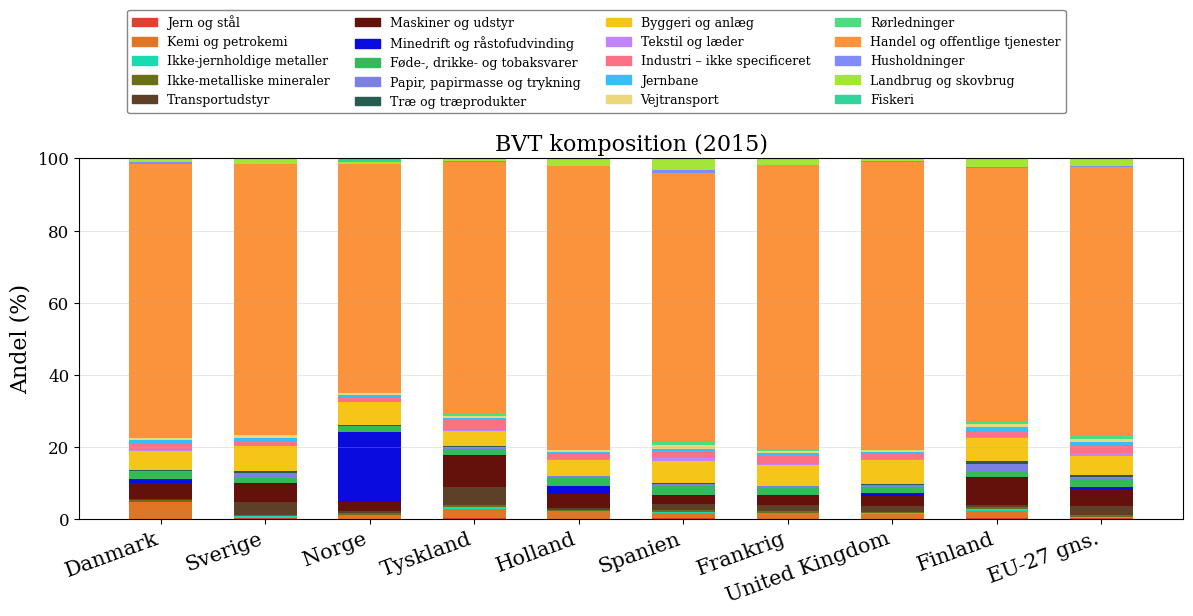

In [29]:
# 1. get data
df_ = df[df.year.eq(2015)][['geo','nrg_bal','label','gva_meur']].copy().reset_index(drop=True)
df_.loc[df_['geo'] == 'EU27_2020', 'gva_meur'] /= 27

# 2. country sum & shares
tots        = df_.groupby('geo').gva_meur.sum()
df_['share'] = df_['geo'].map(tots).__rtruediv__(df_['gva_meur']) * 100

# 3. pivot to wide: rows = countries, cols = sectors (var_groups order)
#    fillna(0) after reindex: fill_value only covers missing index entries,
#    NaN cells from pivot (missing source data) need a separate fillna
available   = set(df_['nrg_bal'].unique())
sectors_all = [s for s in var_groups.subs if s in available]
sec_colors  = {s: SEC_PALETTE[i] for i, s in enumerate(sectors_all)}
COUNTRIES   = var_groups.countries
x_labels    = [var_groups.country_names[c] for c in COUNTRIES]

wide = (df_.pivot_table(index='geo', columns='nrg_bal', values='share', aggfunc='sum')
          .reindex(index=COUNTRIES, columns=sectors_all, fill_value=0)
          .fillna(0))

# 4. plot
x_pos  = np.arange(len(COUNTRIES))
fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(COUNTRIES))
for nrg in sectors_all:
    heights = wide[nrg].to_numpy()
    ax.bar(x_pos, heights, bottom=bottom, color=sec_colors[nrg], width=0.6, linewidth=0)
    bottom += heights

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=20, ha='right')
ax.set_ylim(0, 100)
ax.set_ylabel("Andel (%)")
ax.set_title("BVT komposition (2015)")
ax.grid(axis="y", linewidth=0.6, alpha=0.35)

handles = [plt.Rectangle((0,0),1,1, color=sec_colors[s], label=var_groups.labels[s])
           for s in sectors_all]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=4,
           frameon=True, framealpha=0.95, edgecolor="0.5", fancybox=True, fontsize=9)

plt.tight_layout()
plt.show()

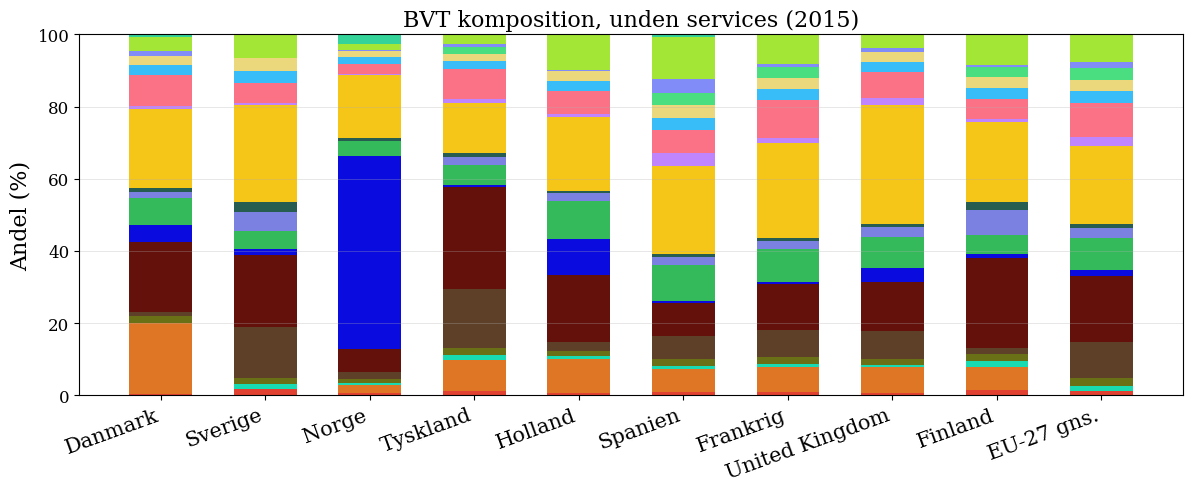

In [30]:
# Same as above but services (FC_OTH_CP_E) excluded, re-normalised to 100 %
sectors_ex = [s for s in sectors_all if s != 'FC_OTH_CP_E']

wide_ex = wide[sectors_ex].div(wide[sectors_ex].sum(axis=1), axis=0) * 100

x_pos  = np.arange(len(COUNTRIES))
fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(COUNTRIES))
for nrg in sectors_ex:
    heights = wide_ex[nrg].to_numpy()
    ax.bar(x_pos, heights, bottom=bottom, color=sec_colors[nrg], width=0.6, linewidth=0)
    bottom += heights

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=20, ha='right')
ax.set_ylim(0, 100)
ax.set_ylabel("Andel (%)")
ax.set_title("BVT komposition, unden services (2015)")
ax.grid(axis="y", linewidth=0.6, alpha=0.35)

handles = [plt.Rectangle((0,0),1,1, color=sec_colors[s], label=var_groups.labels[s])
           for s in sectors_ex]
# fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=4,
#            frameon=True, framealpha=0.95, edgecolor="0.5", fancybox=True, fontsize=9)

plt.tight_layout()
plt.show()